# Aiyagari (1994)の定常均衡を解く

1. ある利子率 $r_0$ のもとで企業の資本需要 $K_0$ と賃金 $w_0$ を求める
2. $r_0$ と $w_0$ を所与として、個人の効用最大化問題を解き政策関数を得る
3. 政策関数をもとに、状態変数の定常分布を求め、総資本供給 $A_0$ を求める
4. $K_0$ と $A_0$ の差が小さければ計算を終了し、そうでなければステップ1で $r_0$ を調整し各ステップを繰り返す

In [1]:
# load functrions made in advance
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi1.jl")
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi2.jl")
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi3.jl")
include("../quant_macro_book/chapter5/julia/tauchen.jl")

# import libraries
using Plots
using Optim
using Random
using Distributions 
using LaTeXStrings
using JLD


In [2]:
# create constructer that contains parameters
struct Model{TI<:Integer, TF<:AbstractFloat}
    
    mu::TF                # risk aversion (=3 baseline)
    beta::TF              # subjective discount factor 
    delta::TF             # depreciation
    alpha::TF             # capital's share of income
    b::TF                 # borrowing limit
    Nl::TI                # number of discretized states
    s::Array{TF,1}        # (exponentialed) discretized states of log labor earnings
    prob::Array{TF,2}     # transition matrix of the Markov chain
    labor::TF             # aggregate labor supply

    Nk::TI                # grid size for capital (state variable)
    maxK::TF              # maximum value of capital grid
    curvK::TF             # a parameter controlling grid width

    Nk2::TI               # grid size for capital (control variable)

    NT::TI                # transition period

end

In [3]:
# ===================== #
#  SET PARAMETER VALUES #
# ===================== #

mu    = 3.0;             # risk aversion (=3 baseline)             
beta  = 0.96;            # subjective discount factor 
delta = 0.08;            # depreciation
alpha = 0.36;            # capital's share of income
b     = 3.0;             # borrowing limit

Nk = 300;
maxK = 20.0;
curvK = 2.0;
Nk2 = 800;

NT = 200;

In [4]:
# ================================================= #
#  COMPUTE TRANSITION MATRIX OF LABOR PRODUCTIVITY  #
# ================================================= #

# ROUTINE tauchen.m TO COMPUTE TRANSITION MATRIX, GRID OF AN AR(1) AND
# STATIONARY DISTRIBUTION
# approximate labor endowment shocks with seven states Markov chain
# log(s_{t}) = rho*log(s_{t-1})+e_{t} 
# e_{t}~ N(0,sig^2)

Nl  = 7;             # number of discretized states
rho = 0.6;           # first-order autoregressive coefficient
sig = 0.4;           # intermediate value to calculate sigma (=0.4 BASE)

# prob   : transition matrix of the Markov chain
# logs   : the discretized states of log labor earnings
# invdist: the invariant distribution of Markov chain

M = 2.0;
logs,prob,invdist = tauchen(Nl,rho,sig,M);
s = exp.(logs);
labor = s'*invdist;
println(logs)
println(prob)
println(invdist)

[-1.0, -0.6666666666666666, -0.3333333333333333, 0.0, 0.3333333333333333, 0.6666666666666666, 1.0]
[0.27983446359970576 0.31887186208321794 0.2619634268674542 0.11169010115661171 0.024660383057955815 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 0.31887186208321794 0.20154426005488835 0.06606573088977274 0.01120099399075214 0.001023478664292532; 0.0566727546097629 0.16995459776710528 0.30657939947575413 0.2871345789825922 0.13959951230096823 0.03516662026158213 0.004892536602234987; 0.018610425189886332 0.0870393484769689 0.2328113458438344 0.3230777609786207 0.23281134584383445 0.08703934847696893 0.018610425189886315; 0.004892536602234982 0.03516662026158211 0.13959951230096826 0.2871345789825923 0.306579399475754 0.1699545977671052 0.056672754609762954; 0.0010234786642925847 0.011200993990752113 0.0660657308897727 0.20154426005488835 0.31887186208321794 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 0.02466038

In [5]:
# ============================================ #
#  CREATE CONSTRUCTER THAT CONTAINS PARAMETER  #
# ============================================ #

m = Model(mu,beta,delta,alpha,b,Nl,s,prob,labor, Nk, maxK, curvK, Nk2, NT) 

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 3.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 … 0.01120099399075214 0.001023478664292532; … ; 0.0010234786642925847 0.011200993990752113 … 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 … 0.31887186208321794 0.27983446359970576], 1.1257073928218677, 300, 20.0, 2.0, 800, 200)

### ステップ1：$r_0$のもとで$K_0$と$r_0$を求める

In [6]:
rate0 = 0.02; # initial guess

In [7]:
function calculate_K0(m, r)
    K0 = m.labor*(m.alpha/(r+m.delta))^(1/(1-m.alpha)); # caputal demand
    return K0
end
K0 = calculate_K0(m, rate0)
println("K0 = ", K0)

function calculate_w0(m, r)
    w0 = (1-m.alpha)*((m.alpha/(r+m.delta))^m.alpha)^(1/(1-m.alpha));
    return w0
end
w0 = calculate_w0(m, rate0)
println("w0 = ", w0)

K0 = 8.33006088438967
w0 = 1.3155281045708864


### ステップ2： 個人の効用最大化から政策関数を求める

1. 資産のグリッドを作る（制御変数の資産と状態変数の資産でグリッドの数が違う場合は、前者を後者に変換する関数も用意する）
2. VFIを解いて政策関数を得る

#### ステップ2.1：資産のグリッドを作る

In [8]:
function generate_capital_grid(m, r=nothing, wage=nothing)

    if (r === nothing) && (wage === nothing) # if these are not specified, use no-borrowing condition
        phi = 0.0;
    else
        # borrowing limit
        if r <= 0.0
            phi = m.b;
        else
            phi = min(m.b,wage*m.s[1]/r);
        end
    end

    # -phi is borrowing limit, b is adhoc
    # the second term is natural limit

    # capital grid (need define in each iteration since it depends on r/phi)
    minK = -phi;                                  # borrowing constraint

    gridk = zeros(m.Nk);
    gridk[1] = minK;
    for kc in 2:m.Nk
        gridk[kc]=gridk[1]+(m.maxK-minK)*((kc-1)/(m.Nk-1))^m.curvK;
    end

    gridk2 = zeros(m.Nk2);
    gridk2[1] = minK;
    for kc in 2:m.Nk2
        gridk2[kc]=gridk2[1]+(m.maxK-minK)*((kc-1)/(m.Nk2-1))^m.curvK;
    end

    return gridk, gridk2
end
grids = generate_capital_grid(m, rate0, w0);

In [9]:
function translate_capital_grid(m, grids)

    gridk, gridk2 = grids

    # =================================================== #
    #  SPLIT GRID in gridk2 TO NEARBY TWO GRIDS IN gridk  #
    # =================================================== #
    
    # calculate node and weight for interpolation  
    kc1vec=zeros(m.Nk2);
    kc2vec=zeros(m.Nk2);

    prk1vec=zeros(m.Nk2);
    prk2vec=zeros(m.Nk2);

    for kc in 1:m.Nk2

        xx = gridk2[kc];

        if xx >= gridk[m.Nk]

            kc1vec[kc] = m.Nk;
            kc2vec[kc] = m.Nk;

            prk1vec[kc] = 1.0;
            prk2vec[kc] = 0.0;

        else

            ind = 1;
            while xx > gridk[ind+1]
                ind += 1
                if ind+1 >= m.Nk
                    break
                end
            end

            kc1vec[kc] = ind

            if ind < m.Nk

                kc2vec[kc] = ind+1;
                dK=(xx-gridk[ind])/(gridk[ind+1]-gridk[ind]);
                prk1vec[kc] = 1.0-dK;
                prk2vec[kc] = dK;

            else

                kc2vec[kc] = ind;
                prk1vec[kc] = 1.0;
                prk2vec[kc] = 0.0;

            end
        end
    end

    return kc1vec, kc2vec, prk1vec, prk2vec
end
capital_grid_translations = translate_capital_grid(m, grids);

#### ステップ2.2：効用最大化問題をVFIで解き、政策関数を得る

In [10]:
function solve_VFI(m, r0, K0, wage, grids, capital_grid_translations; tau=0)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # initialize some variables
    kfunG = zeros(m.Nl,m.Nk);    # new index of policy function 
    kfun = similar(kfunG);     # policy function   
    v = zeros(m.Nl,m.Nk);        # old value function
    tv = similar(kfunG);       # new value function
    kfunG_old = zeros(m.Nl,m.Nk) # old policy function 

    err     = 10;   # error between old policy index and new policy index
    maxiter = 2000; # maximum number of iteration 
    iter    = 1;    # iteration counter

    while (err > 0) & (iter < maxiter)

        # tabulate the utility function such that for zero or negative
        # consumption utility remains a large negative number so that
        # such values will never be chosen as utility maximizing

        for kc in 1:m.Nk # k(STATE)
            for lc in 1:m.Nl # l

                kccmax = m.Nk2 # maximum index that satisfies c>0.0 
                vtemp = -1000000 .* ones(m.Nk2); # initizalization

                for kcc in 1:m.Nk2 # k'(CONTROL)

                    # amount of consumption given (k,l,k')
                    cons = m.s[lc]*wage + (1 + r0 * (1 - tau))*gridk[kc] - gridk2[kcc] + tau * r0 * K0;

                    if cons <= 0.0
                        # penalty for c<0.0
                        # once c becomes negative, vtemp will not be updated(=large negative number)
                        kccmax = kcc-1; 
                        break  
                    end

                    util = (cons^(1-mu)) / (1-mu);

                    # interpolation of next period's value function
                    # find node and weight for gridk2 (evaluating gridk2 in gridk) 
                    kcc1 = Int(kc1vec[kcc]);
                    kcc2 = Int(kc2vec[kcc]);
                    
                    vpr = 0.0; # next period's value function given (l,k')
                    for lcc in 1:m.Nl # expectation of next period's value function
                        
                        vpr += m.prob[lc,lcc]*(prk1vec[kcc]*v[lcc,kcc1] + prk2vec[kcc]*v[lcc,kcc2]);
                    
                    end

                    vtemp[kcc] = util + m.beta*vpr;

                end

                # find k' that  solves bellman equation
                t1,t2 = findmax(vtemp[1:kccmax]); # subject to k' achieves c>0
                tv[lc,kc] = t1;
                kfunG[lc,kc] = t2;
                kfun[lc,kc] = gridk2[t2];

            end
        end

        v = copy(tv);
        err = maximum(abs.(kfunG-kfunG_old));
        # println([iter,err])
        #flush(stdout)
        kfunG_old = copy(kfunG);
        iter += 1

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl VFI: iteration reached max: iter=$iter,e rr=$err")
    end

    return kfun, kfunG, v
end

solve_VFI (generic function with 1 method)

In [11]:
kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations);
kfun

7×300 Matrix{Float64}:
 -3.0       -3.0       -3.0       …  18.1946  18.3607  18.5275  18.6949
 -3.0       -3.0       -3.0          18.3607  18.5275  18.6949  18.8069
 -2.92704   -2.92704   -2.92704      18.639   18.7509  18.9191  19.0881
 -2.73354   -2.73354   -2.73354      18.9191  19.0881  19.2577  19.3711
 -2.37226   -2.37226   -2.37226      19.3711  19.5417  19.6559  19.7703
 -1.79347   -1.79347   -1.79347   …  19.885   20.0     20.0     20.0
 -0.924815  -0.924815  -0.924815     20.0     20.0     20.0     20.0

### ステップ3：政策関数から状態変数の定常分布を求め、総資本供給を求める

1. 状態変数の定常分布を求める
2. 総資本供給を求める

#### ステップ3.1：状態変数の定常分布を求める

In [12]:
function derive_stationary_distribution(m, r0, kfun, kfunG, wage, grids, capital_grid_translations)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations
    
    # calculate stationary distribution
    mea0=ones(m.Nl,m.Nk)/(m.Nl*m.Nk); # old distribution
    mea1=zeros(m.Nl,m.Nk); # new distribution
    err=1;
    errTol=0.00001;
    maxiter=2000;
    iter=1;

    while (err > errTol) & (iter < maxiter)

        for kc in 1:m.Nk # k
            for lc in 1:m.Nl # l
                
                kcc = Int(kfunG[lc,kc]); # index of k'(k,l)

                # interpolation of policy function 
                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:m.Nl # l'

                    mea1[lcc,kcc1] += m.prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc]
                    mea1[lcc,kcc2] += m.prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc]
                    
                end
            end
        end

        err = maximum(abs.(mea1-mea0));
        mea0 = copy(mea1);
        iter += 1;
        mea1 = zeros(m.Nl,m.Nk);

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl INVARIANT DIST: iteration reached max: iter=$iter, err=$err")
    end

    return mea0
end
mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)

7×300 Matrix{Float64}:
 0.000534274  9.25771e-7  4.63969e-6  0.0  …  8.09797e-7  5.56569e-7
 0.000709902  1.7406e-6   8.72338e-6  0.0     6.24777e-6  6.58218e-6
 0.000684757  2.11872e-6  1.06184e-5  0.0     2.74843e-5  4.29858e-5
 0.000356207  1.33915e-6  6.71142e-6  0.0     6.59195e-5  0.000149906
 9.97751e-5   4.3897e-7   2.19999e-6  0.0     8.80865e-5  0.000281065
 1.49675e-5   7.44243e-8  3.72993e-7  0.0  …  6.68721e-5  0.000284272
 1.24375e-6   6.80044e-9  3.40818e-8  0.0     3.74921e-5  0.00020795

#### ステップ3.2：総資本供給を求める

In [13]:
function calculate_capital_supply(mea0, kfun)
    return sum(sum(mea0 .* kfun))
end
K1 = calculate_capital_supply(mea0, kfun)

3.9276366271594356

### ステップ4：資本の需要と供給を比べ、差が大きければ $r_0$ を調節する

ここでは、需要が供給より小さい限り利子率を少しずつ上げていき、需要が供給を上回った時点で計算を止める

In [14]:
println("Capital demand: ", K0)
println("Capital supply: ", K1)

Capital demand: 8.33006088438967
Capital supply: 3.9276366271594356


In [15]:
function solve_stationary_equilibrium(m; tau=0, adj=0.001, rate0=0.02)

    # Pre-declare everything you want to survive the loop
    K0   = 0.0
    K1   = 0.0
    w0   = 0.0
    mea0 = zeros(m.Nl, m.Nk)
    v = zeros(m.Nl, m.Nk)
    grid1 = zeros(m.Nk)

    while true
        # step 1
        K0 = calculate_K0(m, rate0)
        w0 = calculate_w0(m, rate0)

        # step 2
        grids = generate_capital_grid(m, rate0, w0);
        grid1 = grids[1]
        capital_grid_translations = translate_capital_grid(m, grids);

        # step 3
        kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations; tau=tau);

        # step 4
        mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)
        K1 = calculate_capital_supply(mea0, kfun)

        println(
            "r0: ", round(rate0, digits=4), 
            ", K0: ", round(K0, digits=3), 
            ", K1: ", round(K1, digits=3),
            )

        # stop if capital demand < capital supply
        K0 < K1 && break

        rate0 += adj

    end

    return (; rate0, K1, w0, mea0, grid1, v)

end

solve_stationary_equilibrium (generic function with 1 method)

In [16]:
res = solve_stationary_equilibrium(m);

r0: 0.02, K0: 8.33, K1: 3.928
r0: 0.021, K0: 8.202, K1: 4.092
r0: 0.022, K0: 8.076, K1: 4.277
r0: 0.023, K0: 7.954, K1: 4.45
r0: 0.024, K0: 7.835, K1: 4.602
r0: 0.025, K0: 7.719, K1: 4.802
r0: 0.026, K0: 7.605, K1: 4.992
r0: 0.027, K0: 7.494, K1: 5.179
r0: 0.028, K0: 7.386, K1: 5.389
r0: 0.029, K0: 7.281, K1: 5.581
r0: 0.03, K0: 7.177, K1: 5.785
r0: 0.031, K0: 7.077, K1: 6.002
r0: 0.032, K0: 6.978, K1: 6.22
r0: 0.033, K0: 6.882, K1: 6.44
r0: 0.034, K0: 6.788, K1: 6.676
r0: 0.035, K0: 6.696, K1: 6.964


# 移行過程を求める

In [ ]:
m_transition = Model(
    mu, beta, delta, alpha, 0.0, Nl, s, prob, labor, Nk, maxK, curvK, Nk2, NT
    )

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 0.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 … 0.01120099399075214 0.001023478664292532; … ; 0.0010234786642925847 0.011200993990752113 … 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 … 0.31887186208321794 0.27983446359970576], 1.1257073928218677, 300, 20.0, 2.0, 1600, 200)

In [100]:
res_SS0 = solve_stationary_equilibrium(m_transition; adj=0.0002, rate0=0.025);

r0: 0.025, K0: 7.719, K1: 7.048
r0: 0.0252, K0: 7.696, K1: 7.081
r0: 0.0254, K0: 7.673, K1: 7.104
r0: 0.0256, K0: 7.65, K1: 7.139
r0: 0.0258, K0: 7.628, K1: 7.164
r0: 0.026, K0: 7.605, K1: 7.2
r0: 0.0262, K0: 7.583, K1: 7.227
r0: 0.0264, K0: 7.561, K1: 7.257
r0: 0.0266, K0: 7.538, K1: 7.287
r0: 0.0268, K0: 7.516, K1: 7.323
r0: 0.027, K0: 7.494, K1: 7.351
r0: 0.0272, K0: 7.473, K1: 7.385
r0: 0.0274, K0: 7.451, K1: 7.414
r0: 0.0276, K0: 7.429, K1: 7.449


In [101]:
r_SS0 = res_SS0.rate0;
K_SS0 = res_SS0.K1;
T_SS0 = r_SS0 * K_SS0 * 0;
v_SS0 = res_SS0.v;
mea_SS0 = res_SS0.mea0;

In [102]:
tau = 0.1;
res_SS1 = solve_stationary_equilibrium(m_transition; tau=tau, adj=0.0002, rate0=0.025);

r0: 0.025, K0: 7.719, K1: 6.57
r0: 0.0252, K0: 7.696, K1: 6.596
r0: 0.0254, K0: 7.673, K1: 6.619
r0: 0.0256, K0: 7.65, K1: 6.64
r0: 0.0258, K0: 7.628, K1: 6.668
r0: 0.026, K0: 7.605, K1: 6.698
r0: 0.0262, K0: 7.583, K1: 6.721
r0: 0.0264, K0: 7.561, K1: 6.751
r0: 0.0266, K0: 7.538, K1: 6.776
r0: 0.0268, K0: 7.516, K1: 6.808
r0: 0.027, K0: 7.494, K1: 6.831
r0: 0.0272, K0: 7.473, K1: 6.86
r0: 0.0274, K0: 7.451, K1: 6.887
r0: 0.0276, K0: 7.429, K1: 6.913
r0: 0.0278, K0: 7.408, K1: 6.941
r0: 0.028, K0: 7.386, K1: 6.966
r0: 0.0282, K0: 7.365, K1: 6.989
r0: 0.0284, K0: 7.344, K1: 7.016
r0: 0.0286, K0: 7.323, K1: 7.043
r0: 0.0288, K0: 7.302, K1: 7.067
r0: 0.029, K0: 7.281, K1: 7.102
r0: 0.0292, K0: 7.26, K1: 7.128
r0: 0.0294, K0: 7.239, K1: 7.157
r0: 0.0296, K0: 7.218, K1: 7.186
r0: 0.0298, K0: 7.198, K1: 7.216


In [103]:
r_SS1 = res_SS1.rate0;
K_SS1 = res_SS1.K1;
T_SS1 = r_SS1 * K_SS1 * tau;
v_SS1 = res_SS1.v;

In [104]:
function make_initial_guesses(m, K_SS0, K_SS1)

    # ============================== #
    #  INITIAL GUESS OF KT0 and TT0  #
    # ============================== #

    KT0 = K_SS1 .* ones(m.NT);
    # TT0 = T_SS1 .* ones(m.NT);

    NT0 = 30; # considering relatively quick convergence to the new steady state

    intK=(K_SS1-K_SS0)/(NT0-1);
    # intT=(T_SS1-T_SS0)/(NT0-1);

    for tc=1:NT0
        KT0[tc] = K_SS0+intK*(tc-1);
        #TT0[tc] = T_SS0+intT*(tc-1);    # let T to jump to final SS value
    end

    # ================================ #
    #  rT0 BASED ON INITIAL GUESS KT0  #
    # ================================ #

    rT0 = zeros(m.NT);

    for tc in 1:m.NT
        rT0[tc] = m.alpha * ((KT0[tc] / m.labor)^(m.alpha - 1)) - m.delta;
    end

    TT0 = KT0 .* rT0 .* tau;

    return TT0, KT0, rT0
end

make_initial_guesses (generic function with 1 method)

In [105]:
TT0, KT0, rT0 = make_initial_guesses(m_transition, K_SS0, K_SS1);

In [106]:
function compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
    )

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    r0 = rT0[tc];
    T0 = TT0[tc];
    # wage = (1-m.alpha)*((m.alpha/(r0+m.delta))^m.alpha)^(1/(1-m.alpha));
    wage = calculate_w0(m, r0);

    # initialization
    kfunG = zeros(m.Nl,m.Nk); # solution grid
    vfun1 = zeros(m.Nl,m.Nk); # new value function
    kfun = zeros(m.Nl,m.Nk);  # solution level

    for kc in 1:m.Nk
        for lc in 1:m.Nl

            vtemp = -1000000 .* ones(m.Nk2); 
            kccmax = m.Nk2;

            for kcc in 1:m.Nk2 

                cons = (
                    m.s[lc] * wage + (1 + r0 * (1 - tau)) * gridk[kc] - gridk2[kcc] + T0
                ); # NOTE: gridk2[kcc] & r0 & T0

                if cons <= 0.0
                    kccmax = kcc-1; 
                    break  
                end

                util = (cons^(1.0-m.mu)-1.0) / (1.0-m.mu);

                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);
            
                vpr = 0.0; 
                for lcc in 1:m.Nl 

                    vpr += (
                        m.prob[lc,lcc] * (
                            prk1vec[kcc] * vfun0[lcc,kcc1] + prk2vec[kcc] * vfun0[lcc,kcc2]
                        )
                    );
            
                end

                vtemp[kcc] = util + m.beta * vpr;

            end

            t1, t2 = findmax(vtemp[1:kccmax]);
            vfun1[lc,kc] = t1;
            kfunG[lc,kc] = t2;        # solution grid from gridk2
            kfun[lc,kc] = gridk2[t2]; # solution capital(level)

        end

    end

    # update vfun0 for next period (tc-1)
    vfun0[:, :] .= vfun1;
    
    # update policy function (solution grid)
    kfunGT[tc,:,:] .= kfunG;

    # update capital (level)
    kfunT[tc,:,:] .= kfun;

    return nothing

end

compute_value_function_backwards! (generic function with 1 method)

In [107]:
vfun0 = copy(res_SS1.v);

# policy function(initialization)
kfunGT = zeros(m_transition.NT, m_transition.Nl, m_transition.Nk);
kfunT = similar(kfunGT);

tc = m_transition.NT;

In [108]:
compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m_transition, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
)


LoadError: BoundsError: attempt to access 800-element Vector{Float64} at index [801]

In [ ]:
function compute_all_value_function_backwards(
    m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    )

    # policy function(initialization)
    kfunGT = zeros(m.NT,m.Nl,m.Nk);
    kfunT = similar(kfunGT);

    vfun0 = copy(v_SS1);

    for tc in NT:-1:1
        compute_value_function_backwards!(
            vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, grids, capital_grid_translations, tau
        )
    end

    return kfunGT, kfunT
end

compute_all_value_function_backwards (generic function with 1 method)

In [ ]:
kfunGT, kfunT = compute_all_value_function_backwards(
    m_transition, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    );

In [ ]:
function compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0)

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # ==================================================== #
    # COMPUTE DISTRIBUTION meaT: FROM t=1 TO NT (FORWRAD)  #
    # ==================================================== #

    meaT = zeros(m.NT,m.Nl,m.Nk); # initialization
    meaT[1,:,:] .= copy(mea_SS0); # dist in the initial SS
    
    mea0 = mea_SS0;

    for tc in 1:m.NT-1

        kfunG = copy(kfunGT[tc,:,:]);
        mea1 = zeros(m.Nl,m.Nk); # initialization 

        for kc in 1:m.Nk
            for lc in 1:m.Nl
            
                kcc = Int(kfunG[lc,kc]); # from gridk2

                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:Nl

                    mea1[lcc,kcc1] += prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc];
                    mea1[lcc,kcc2] += prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc];
                
                end
            end
        end

        meaT[tc+1,:,:] = copy(mea1);
        mea0 = copy(mea1);

    end

    return meaT
end

compute_distribution_t (generic function with 1 method)

In [ ]:
meaT = compute_distribution_t(m_transition, kfunGT, capital_grid_translations, mea_SS0);

In [ ]:
function compute_capital(m, KT0, kfunT, meaT)
    # ============ #
    #  COMPUTE KT1 #
    # ============ #

    KT1 = zeros(m.NT);
    KT1[1] = KT0[1]; # predetermined

    for tc in 1:m.NT-1

        kfun = copy(kfunT[tc,:,:]); # saving for the next period
        mea0 = meaT[tc,:,:];

        KT1[tc+1] = sum(mea0 .* kfun); #capital at the beggining of next period
    end

    return KT1

end

compute_capital (generic function with 1 method)

In [ ]:
KT1 = compute_capital(m_transition, KT0, kfunT, meaT);

In [ ]:
function update_variables!(TT0, KT0, rT0, m, KT1, tau; adjK = 0.04)
    KT0 .+= adjK .* (KT1 - KT0)
    rT0[:] .= m.alpha .* ((KT0 ./ m.labor).^(m.alpha - 1)) .- m.delta
    TT0[:] .= KT0 .* rT0 .* tau

    return nothing
end

update_variables! (generic function with 1 method)

In [ ]:
update_variables!(TT0, KT0, rT0, m_transition, KT1, tau)

In [109]:
function derive_transition(m, K_SS0, K_SS1, v_SS1, mea_SS0, tau)

    grids = generate_capital_grid(m);
    capital_grid_translations = translate_capital_grid(m, grids);

    errKTol = 1e-4;
    errK = 1;
    maxiterTR = 150;
    iterTR = 1;

    KT0_iteration_history = zeros(m.NT, maxiterTR);

    TT0, KT0, rT0 = make_initial_guesses(m, K_SS0, K_SS1)

    while (errK > errKTol) && (iterTR < maxiterTR)

        println(iterTR)

        kfunGT, kfunT = compute_all_value_function_backwards(
            m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
            );

        meaT = compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0);

        KT1 = compute_capital(m, KT0, kfunT, meaT);

        errK = maximum(abs.(KT1 - KT0));
        println(errK)
        if errK > errKTol
            update_variables!(TT0, KT0, rT0, m, KT1, tau)
        end

        KT0_iteration_history[:, iterTR] = KT0;

        iterTR += 1;

    end

    return KT0, KT0_iteration_history

end

derive_transition (generic function with 1 method)

In [110]:
KT_transition, KT0_iteration_history = derive_transition(m_transition, K_SS0, K_SS1, v_SS1, mea_SS0, tau);

1
0.0761169976087297
2
0.0682420092575633
3
0.060413116262144406
4
0.05373383393289455
5
0.04626174622581569
6
0.04234548089799883
7
0.03995708941689635
8
0.03772134552370865
9
0.035520575208610516
10
0.033501192506125044
11
0.0316610099371788
12
0.029886712976225915
13
0.02831054456560622
14
0.026664484814755696
15
0.025214370897630012
16
0.023899712740772294
17
0.02255928773389826
18
0.02128440108623053
19
0.020113084523584845
20
0.019035702823527956
21
0.018079531478838895
22
0.017118331897678196
23
0.01612469867110189
24
0.015254226111864
25
0.014443601810792295
26
0.013674210232426098
27
0.012955840308977784
28
0.012278542912009804
29
0.01167257873343086
30
0.01109750395803033
31
0.01051995652698956
32
0.010011401731017777
33
0.009518018227739233
34
0.0090371818953221
35
0.008612649374929227
36
0.008159574888898291
37
0.007776935156322828
38
0.007375737528771076
39
0.007008902332878542
40
0.006639491479110582
41
0.006297910740083346
42
0.005943394190267348
43
0.005634418675423802


In [111]:
rT_transition = m_transition.alpha .* ((KT_transition ./ m_transition.labor).^(m_transition.alpha .- 1)) .- m_transition.delta;

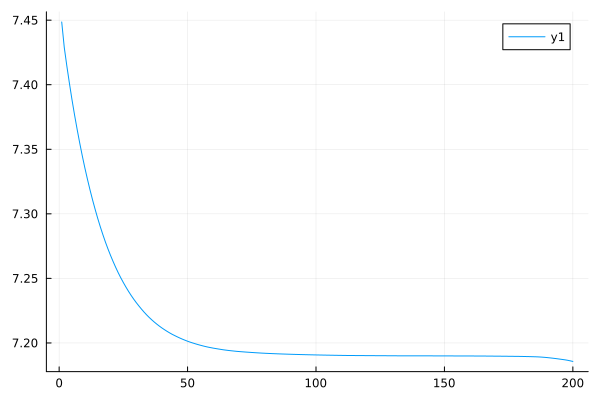

In [112]:
plot(1:NT, KT_transition)

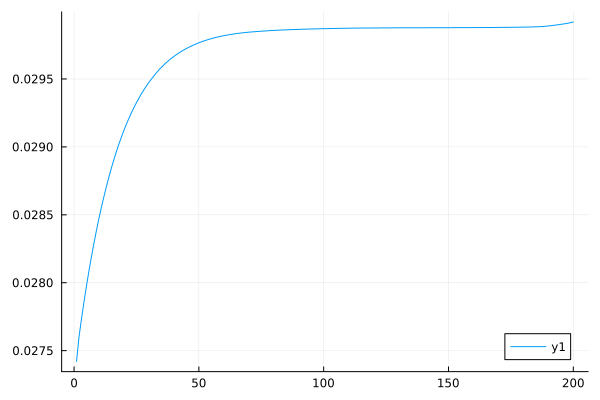

In [113]:
plot(1:NT, rT_transition)

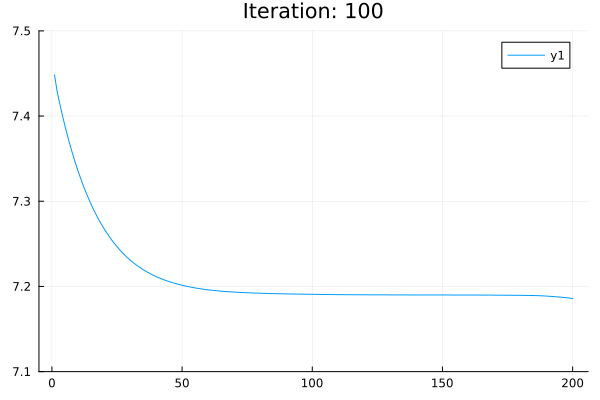

In [119]:
anim = Animation()
for i in 1:100
    current_plot = plot(1:NT, KT0_iteration_history[:, i], title="Iteration: $i")
    plot!(ylims=(7.1, 7.5))
    display(current_plot)
    sleep(0.10)
    frame(anim)
    IJulia.clear_output(true)
end